**Lab2-DL: C3-cnn-testing-gradcam.ipynb** (BMED365) | Priority: 2 (recommended)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab2-DL/notebooks/C3-cnn-testing-gradcam.ipynb)

# 🧪 C3: CNN Testing and Evaluation

Updated: 2025-12-22; 2026-01-15 A. Lundervold

**From Nature to Medicine: Test and Evaluate the CNN Model**

---

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

| Objective | Description |
|-----------|-------------|
| **Evaluate model performance** | Calculate accuracy, precision, recall, F1-score on test data |
| **Interpret confusion matrices** | Understand which classes are confused with each other |
| **Apply Grad-CAM** | Visualize which image regions the CNN focuses on |
| **Explain model decisions** | Understand why explainable AI is critical for medical applications |
| **Connect to clinical use** | See how these techniques apply to medical image analysis |

### What You Will Learn

In this notebook we will:
- **Load** the trained model from part 2
- **Test** the model on the test set
- **Evaluate** performance with confusion matrix and metrics
- **Understand** the model's decisions with explainable AI
- **Compare** with medical image analysis

## Prerequisites

This notebook builds on `C2-cnn-training.ipynb`. Make sure you have:
- ✅ Completed part 2
- ✅ Saved the trained model
- ✅ Understood the training process

## 🔧 Environment Setup

We start by setting up the environment and loading the necessary libraries.

In [1]:
import sys
import subprocess
import os

# Sjekk om vi kjører i Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🚀 Kjører i Google Colab")
    
    # Installer nødvendige pakker
    !pip install seaborn --quiet
    
    # Sjekk om mappen allerede eksisterer
    if not os.path.exists('BMED365-2026/Lab2-DL'):
        print(" Laster ned kursmateriell...")
        try:
            !git clone https://github.com/arvidl/BMED365-2026.git
            os.chdir('BMED365-2026/Lab2-DL')
        except:
            print("❌ Kunne ikke laste ned kursmateriell")
            print("Last ned manuelt fra: https://github.com/arvidl/BMED365-2026")
else:
    print("💻 Kjører lokalt eller i Codespaces")
    
print("✅ Miljøoppsett fullført!")

💻 Kjører lokalt eller i Codespaces
✅ Miljøoppsett fullført!


In [2]:
# =============================================================================
# IMPORT REQUIRED LIBRARIES
# =============================================================================

# === Image Processing ===
from PIL import Image  # Must be imported FIRST to avoid name conflict
from IPython.display import Image as IPyImage
import cv2                            # OpenCV for Grad-CAM heatmap overlay

# === Deep Learning (PyTorch) ===
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import datasets

# === Scientific Computing & Visualization ===
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path
import random

# === Machine Learning Evaluation ===
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,            # Precision, recall, F1
    confusion_matrix,                 # TP, FP, TN, FN matrix
    ConfusionMatrixDisplay            # Visualization
)

import pickle
import time
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# REPRODUCIBILITY SETTINGS
# =============================================================================
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("📚 Libraries imported!")
print(f"🎲 Random seed set to {RANDOM_SEED} for reproducibility")

📚 Libraries imported!
🎲 Random seed set to 42 for reproducibility


In [3]:
# Configure device (CPU, GPU, or MPS)
def setup_device():
    """Set up the best available device"""
    if torch.cuda.is_available():
        device = torch.device('cuda')
        print(f"🚀 Using GPU: {torch.cuda.get_device_name(0)}")
        print(f"💾 GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        device = torch.device('mps')
        print("🍎 Using MPS (Apple Silicon)")
    else:
        device = torch.device('cpu')
        print("💻 Using CPU")
    
    return device

device = setup_device()
print(f"✅ Device set to: {device}")

🍎 Using MPS (Apple Silicon)
✅ Device set to: mps


## Load Trained Model and Data

We load the trained model and data that were saved in part 2.

In [4]:
# Load data info from part 1
try:
    with open('flower_data_info.pkl', 'rb') as f:
        data_info = pickle.load(f)
    
    # Unpack data
    X_train = data_info['X_train']
    y_train = data_info['y_train']
    X_val = data_info['X_val']
    y_val = data_info['y_val']
    X_test = data_info['X_test']
    y_test = data_info['y_test']
    class_names = data_info['class_names']
    class_mapping = data_info['class_mapping']
    num_classes = data_info['num_classes']
    
    print("✅ Data loaded from part 1!")
    print(f"📊 Training set: {len(X_train)} images")
    print(f" Validation set: {len(X_val)} images")
    print(f"📊 Test set: {len(X_test)} images")
    print(f" Classes: {class_names}")
    
except FileNotFoundError:
    print("❌ Could not find 'flower_data_info.pkl'")
    print("💡 Make sure you have completed part 1 first!")
    print(" Run '02a_cnn_bildeklassifikasjon.ipynb' first")
    raise

✅ Data loaded from part 1!
📊 Training set: 2569 images
 Validation set: 550 images
📊 Test set: 551 images
 Classes: ['Daisy', 'Dandelion', 'Rose', 'Sunflower', 'Tulip']


In [5]:
# Load trained model
try:
    checkpoint = torch.load('trained_flower_model.pth', map_location=device)
    
    # Load training history
    with open('training_history.pkl', 'rb') as f:
        training_history = pickle.load(f)
    
    print("✅ Trained model loaded!")
    print(f"🏗️ Model architecture: {checkpoint['model_architecture']}")
    print(f"📊 Number of classes: {checkpoint['num_classes']}")
    print(f" Best validation accuracy: {training_history['best_val_acc']:.2f}%")
    
except FileNotFoundError:
    print("❌ Could not find trained model")
    print("💡 Make sure you have completed part 2 first!")
    print(" Run '02b_cnn_trening.ipynb' first")
    raise

✅ Trained model loaded!
🏗️ Model architecture: SimpleCNN
📊 Number of classes: 5
 Best validation accuracy: 74.18%


In [6]:
# Define transformations (same as in part 1)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("✅ Transformations defined!")

✅ Transformations defined!


In [7]:
# Custom Dataset class (same as in part 1)
class FlowerDataset(Dataset):
    """Custom dataset for flower images"""
    
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        label = self.labels[idx]
        
        # Load image
        image = Image.open(image_path).convert('RGB')
        
        # Apply transform
        if self.transform:
            image = self.transform(image)
            
        return image, label

# Create test dataset and DataLoader
test_dataset = FlowerDataset(X_test, y_test, val_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"✅ Test DataLoader created")
print(f"  Test batches: {len(test_loader)}")
print(f"  Test images: {len(test_dataset)}")

✅ Test DataLoader created
  Test batches: 18
  Test images: 551


In [8]:
# Load model architecture
class SimpleCNN(nn.Module):
    """Simple CNN for flower classification"""
    
    def __init__(self, num_classes=5):
        super(SimpleCNN, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        
        # Pooling
        self.pool = nn.MaxPool2d(2, 2)
        
        # Dropout for regularization
        self.dropout = nn.Dropout(0.5)
        
        # Fully connected layers
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, num_classes)
        
    def forward(self, x):
        # Convolutional block 1
        x = self.pool(torch.relu(self.conv1(x)))
        
        # Convolutional block 2
        x = self.pool(torch.relu(self.conv2(x)))
        
        # Convolutional block 3
        x = self.pool(torch.relu(self.conv3(x)))
        
        # Flatten for fully connected layers
        x = x.view(-1, 128 * 28 * 28)
        
        # Fully connected layers
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

# Create model and load weights
model = SimpleCNN(num_classes=num_classes)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()  # Set to evaluation mode

print("✅ Model loaded and set to evaluation mode!")
print(f"🏗️ Model architecture: {model.__class__.__name__}")
print(f"📊 Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

✅ Model loaded and set to evaluation mode!
🏗️ Model architecture: SimpleCNN
📊 Number of parameters: 51,476,549


## Testing the Model

Now we test the model on the test set and collect predictions.

In [9]:
def evaluate_model(model, test_loader, device, class_names):
    """Evaluate the model on the test set"""
    
    model.eval()
    all_predictions = []
    all_labels = []
    all_probabilities = []
    
    print(" Testing the model on the test set...")
    print("⏳ This may take a few minutes...")
    
    start_time = time.time()
    
    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(test_loader):
            data, target = data.to(device), target.to(device)
            
            # Make predictions
            outputs = model(data)
            probabilities = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            # Collect results
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(target.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
            
            # Show progress
            if (batch_idx + 1) % 10 == 0:
                print(f"  Batch {batch_idx + 1}/{len(test_loader)} completed")
    
    test_time = time.time() - start_time
    
    # Convert to numpy arrays
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    all_probabilities = np.array(all_probabilities)
    
    # Calculate accuracy
    accuracy = (all_predictions == all_labels).mean() * 100
    
    print(f"\n✅ Testing completed!")
    print(f"⏱️ Test time: {test_time:.1f} seconds")
    print(f" Test accuracy: {accuracy:.2f}%")
    
    return all_predictions, all_labels, all_probabilities, accuracy

# Test the model
predictions, labels, probabilities, test_accuracy = evaluate_model(model, test_loader, device, class_names)

 Testing the model on the test set...
⏳ This may take a few minutes...
  Batch 10/18 completed

✅ Testing completed!
⏱️ Test time: 4.2 seconds
 Test accuracy: 74.05%


## Confusion Matrix and Metrics

Let's analyze the model's performance with a confusion matrix and detailed metrics.

📊 Generating confusion matrix...


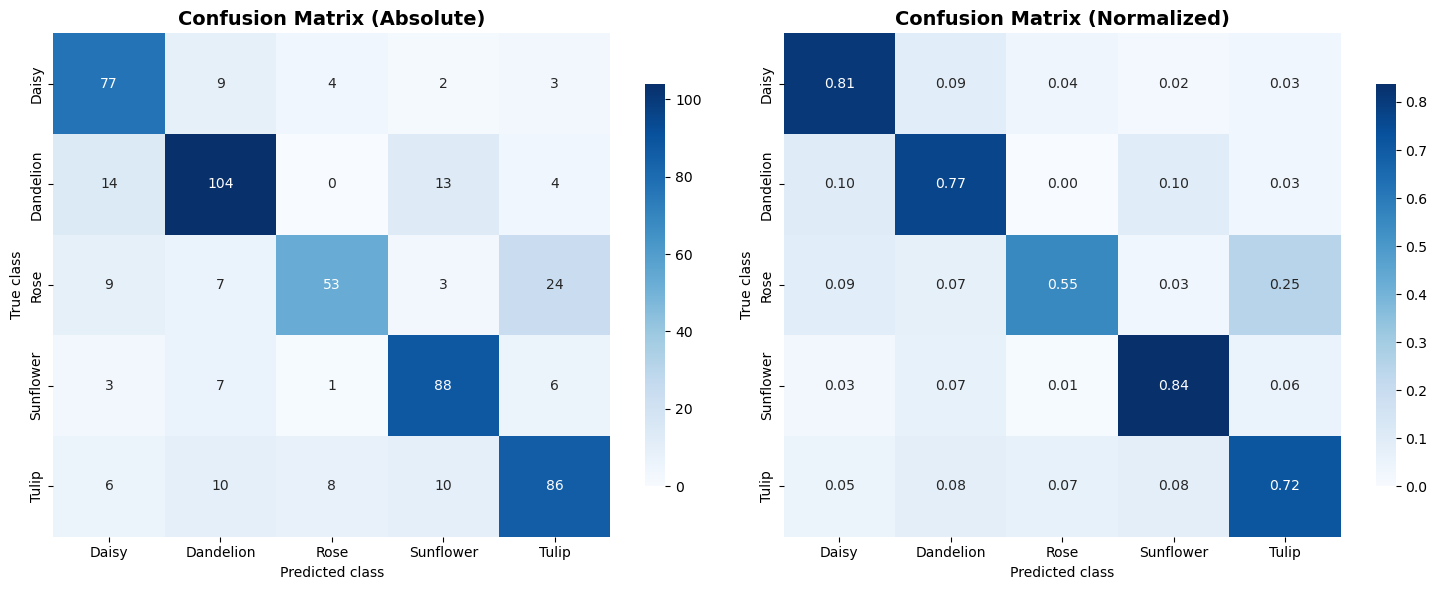

In [10]:
def plot_confusion_matrix(labels, predictions, class_names):
    """Plot confusion matrix"""
    
    # Calculate confusion matrix
    cm = confusion_matrix(labels, predictions)
    
    # Normalize confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Create subplots
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Absolute confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[0], cbar_kws={'shrink': 0.8})
    axes[0].set_title('Confusion Matrix (Absolute)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Predicted class')
    axes[0].set_ylabel('True class')
    
    # Normalized confusion matrix
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[1], cbar_kws={'shrink': 0.8})
    axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Predicted class')
    axes[1].set_ylabel('True class')
    
    plt.tight_layout()
    plt.show()
    
    return cm, cm_normalized

# Plot confusion matrix
print("📊 Generating confusion matrix...")
cm, cm_normalized = plot_confusion_matrix(labels, predictions, class_names)

In [11]:
def print_detailed_metrics(labels, predictions, class_names):
    """Print detailed metrics"""
    
    print(" Detailed metrics:")
    print("=" * 60)
    
    # Classification report
    report = classification_report(labels, predictions, target_names=class_names, output_dict=True)
    
    # Print per-class metrics
    print("\n Per-class metrics:")
    print("-" * 40)
    
    for i, class_name in enumerate(class_names):
        precision = report[class_name]['precision']
        recall = report[class_name]['recall']
        f1 = report[class_name]['f1-score']
        support = report[class_name]['support']
        
        print(f"{class_name:12}: Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}, Support={support}")
    
    # Print overall metrics
    print("\n Overall metrics:")
    print("-" * 40)
    print(f"Accuracy:  {report['accuracy']:.3f}")
    print(f"Macro Avg: Precision={report['macro avg']['precision']:.3f}, Recall={report['macro avg']['recall']:.3f}, F1={report['macro avg']['f1-score']:.3f}")
    print(f"Weighted Avg: Precision={report['weighted avg']['precision']:.3f}, Recall={report['weighted avg']['recall']:.3f}, F1={report['weighted avg']['f1-score']:.3f}")
    
    return report

# Print detailed metrics
metrics_report = print_detailed_metrics(labels, predictions, class_names)

 Detailed metrics:

 Per-class metrics:
----------------------------------------
Daisy       : Precision=0.706, Recall=0.811, F1=0.755, Support=95.0
Dandelion   : Precision=0.759, Recall=0.770, F1=0.765, Support=135.0
Rose        : Precision=0.803, Recall=0.552, F1=0.654, Support=96.0
Sunflower   : Precision=0.759, Recall=0.838, F1=0.796, Support=105.0
Tulip       : Precision=0.699, Recall=0.717, F1=0.708, Support=120.0

 Overall metrics:
----------------------------------------
Accuracy:  0.740
Macro Avg: Precision=0.745, Recall=0.738, F1=0.736
Weighted Avg: Precision=0.745, Recall=0.740, F1=0.737


## Explainable AI - Grad-CAM (Class Activation Maps)

Let's understand which parts of the images the model focuses on by showing the original image, Grad-CAM heatmap, and overlay.

Grad-CAM works by:
- Computing gradients for the predicted class
- Showing which parts of the image influence the prediction the most
- Red areas = important for the prediction
- Blue areas = less important

This provides a more informative understanding of what the model focuses on...

🔍 Testing Grad-CAM on 4 sample images...

📸 Image 1/4
------------------------------


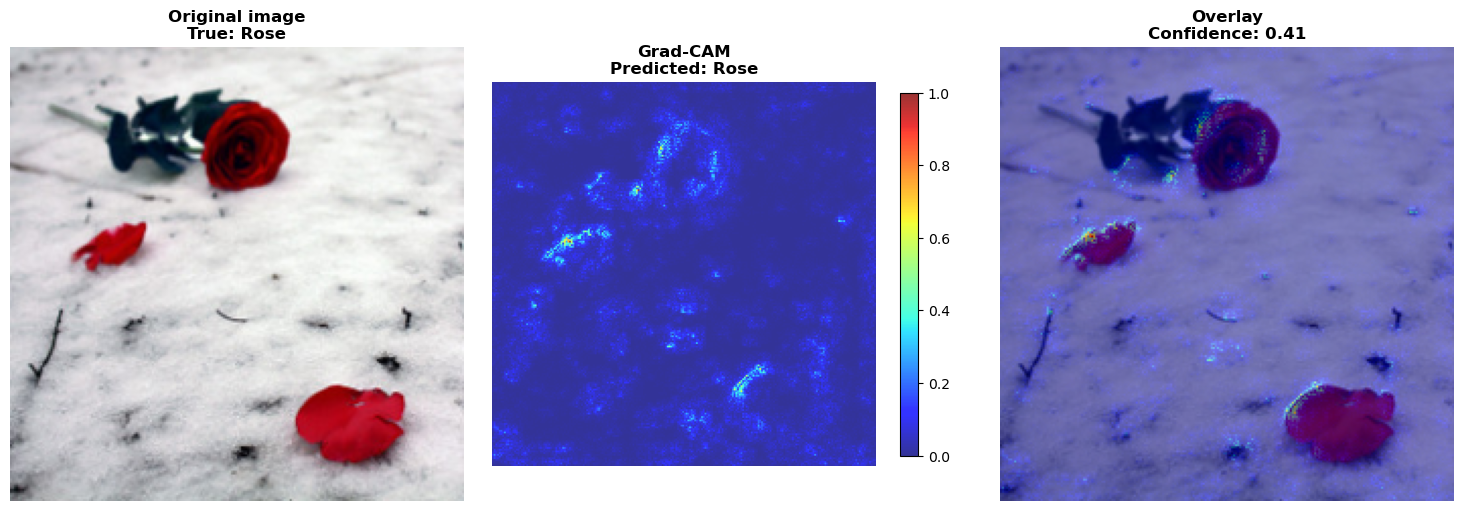

Result: ✅
True class: Rose
Predicted: Rose
Confidence: 0.41

📸 Image 2/4
------------------------------


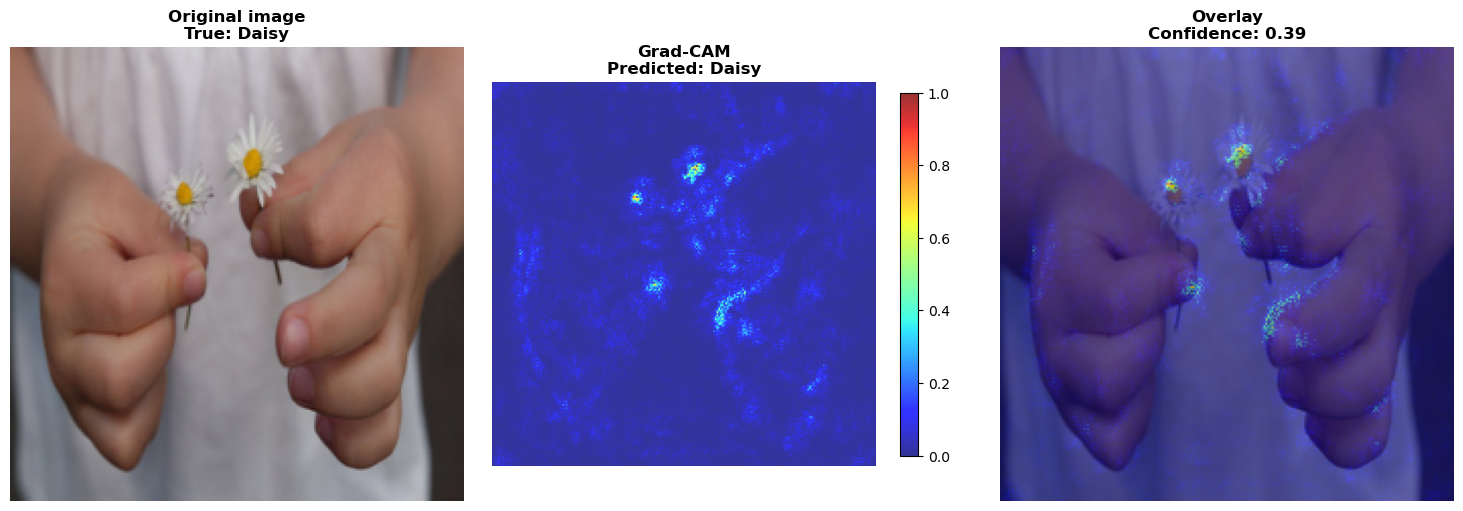

Result: ✅
True class: Daisy
Predicted: Daisy
Confidence: 0.39

📸 Image 3/4
------------------------------


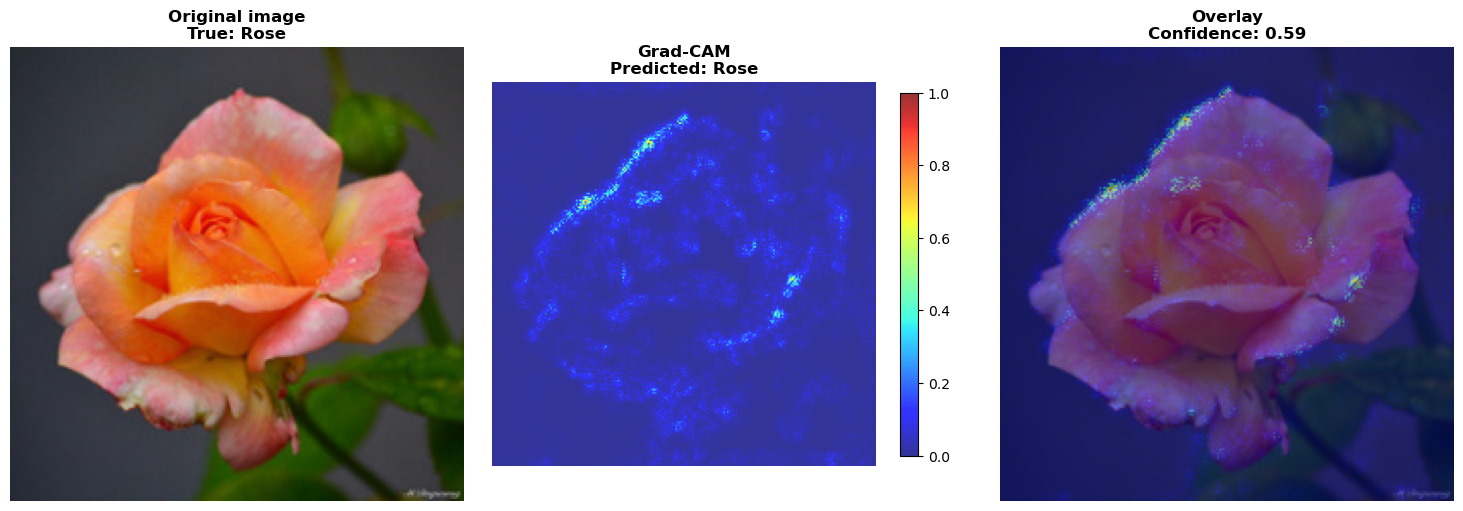

Result: ✅
True class: Rose
Predicted: Rose
Confidence: 0.59

📸 Image 4/4
------------------------------


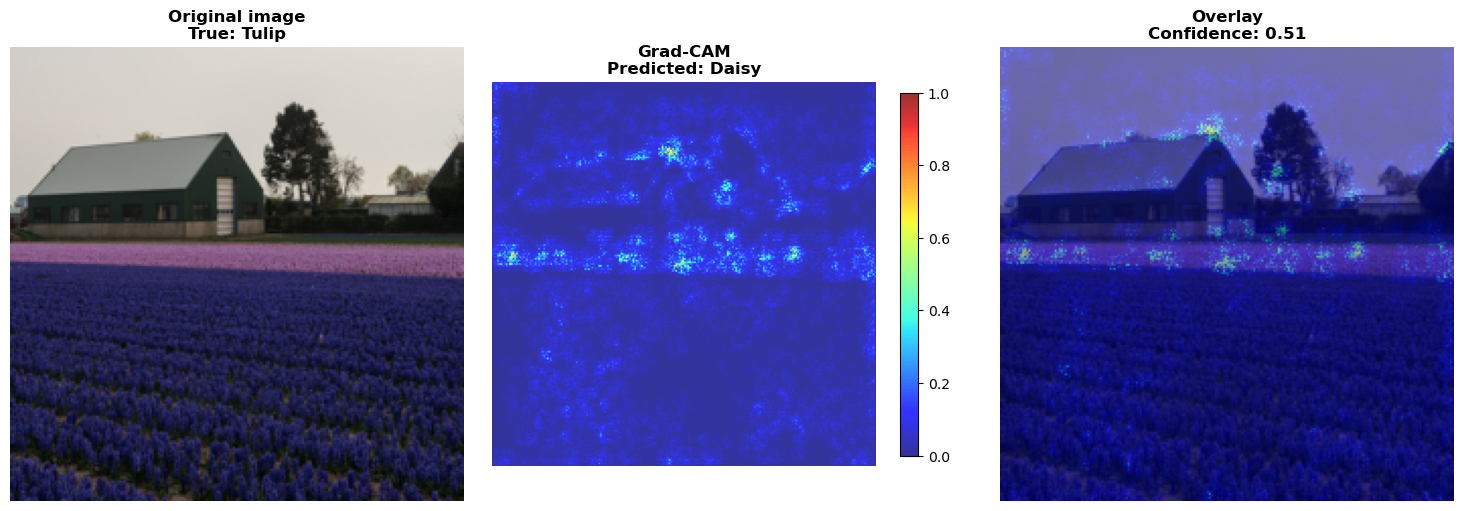

Result: ❌
True class: Tulip
Predicted: Daisy
Confidence: 0.51
⚠️ Misclassification!


In [12]:
# =============================================================================
# GRAD-CAM: GRADIENT-WEIGHTED CLASS ACTIVATION MAPPING
# =============================================================================
# Grad-CAM is an EXPLAINABILITY technique that answers:
#   "Which parts of the image did the CNN focus on to make its decision?"
#
# HOW IT WORKS:
#   1. Forward pass: Get feature maps from last conv layer
#   2. Backward pass: Compute gradients w.r.t. predicted class
#   3. Weight feature maps by gradient importance
#   4. Sum weighted maps → heatmap of important regions
#
# WHY THIS MATTERS FOR MEDICAL AI:
#   - Doctors need to understand WHY the AI made a diagnosis
#   - Catches models that learn spurious correlations
#   - Builds trust in AI-assisted decision making
#   - Required for FDA/regulatory approval in many cases
#
# EXAMPLE: For a chest X-ray, Grad-CAM should highlight:
#   ✅ The lung region (relevant for pneumonia detection)
#   ❌ Not the corner with the hospital logo (spurious correlation)
# =============================================================================

def generate_grad_cam(model, image, class_idx, device):
    """
    Generate Grad-CAM heatmap showing which image regions influenced the prediction.
    
    Args:
        model: Trained CNN model
        image: Input image tensor
        class_idx: Target class for visualization
        device: CPU/GPU/MPS device
    
    Returns:
        grad_cam: Heatmap showing important regions (numpy array)
        predicted_class: Model's predicted class
        confidence: Confidence score for prediction
    """
    
    model.eval()
    
    # Get feature maps from the last convolutional layer
    # This is where high-level features are encoded
    features = None
    def hook_fn(module, input, output):
        nonlocal features
        features = output
    
    # Register hook on the last convolutional layer
    # Hooks let us capture intermediate outputs during forward pass
    hook = model.conv3.register_forward_hook(hook_fn)
    
    # Set input to require gradient
    image = image.unsqueeze(0).to(device)
    image.requires_grad_(True)
    
    # Make prediction
    output = model(image)
    predicted_class = torch.argmax(output, dim=1).item()
    confidence = torch.softmax(output, dim=1)[0][predicted_class].item()
    
    # Compute gradient for the predicted class
    model.zero_grad()
    output[0, predicted_class].backward()
    
    # Get gradient for the input image
    gradients = image.grad.data[0].cpu()  # Shape: (3, 224, 224)
    
    # Generate Grad-CAM by taking the mean of gradients across channels
    grad_cam = torch.mean(torch.abs(gradients), dim=0)  # Shape: (224, 224)
    
    # Normalize Grad-CAM
    if grad_cam.max() > grad_cam.min():
        grad_cam = (grad_cam - grad_cam.min()) / (grad_cam.max() - grad_cam.min())
    
    # Remove hook
    hook.remove()
    
    return grad_cam.numpy(), predicted_class, confidence

def plot_grad_cam_visualization(image, grad_cam, predicted_class, true_class, class_names, confidence):
    """Visualize Grad-CAM results"""
    
    # Denormalize image for visualization
    img = image.clone()
    img = img * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    img = torch.clamp(img, 0, 1)
    img = img.permute(1, 2, 0).numpy()
    
    # Create subplots
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original image
    axes[0].imshow(img)
    axes[0].set_title(f'Original image\nTrue: {class_names[true_class]}', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # Grad-CAM
    im = axes[1].imshow(grad_cam, cmap='jet', alpha=0.8)
    axes[1].set_title(f'Grad-CAM\nPredicted: {class_names[predicted_class]}', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], shrink=0.8)
    
    # Overlay
    axes[2].imshow(img)
    axes[2].imshow(grad_cam, cmap='jet', alpha=0.5)
    axes[2].set_title(f'Overlay\nConfidence: {confidence:.2f}', fontsize=12, fontweight='bold')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

def test_grad_cam_samples(model, test_loader, class_names, num_samples=4):
    """Test Grad-CAM on sample images"""
    
    print(f"🔍 Testing Grad-CAM on {num_samples} sample images...")
    print("=" * 60)
    
    # Get a batch from the test set
    data_iter = iter(test_loader)
    images, labels = next(data_iter)
    
    # Take only the first num_samples images
    images = images[:num_samples]
    labels = labels[:num_samples]
    
    for i in range(num_samples):
        image = images[i]
        true_class = labels[i].item()
        
        print(f"\n📸 Image {i+1}/{num_samples}")
        print("-" * 30)
        
        # Generate Grad-CAM
        grad_cam, predicted_class, confidence = generate_grad_cam(model, image, true_class, device)
        
        # Visualize
        plot_grad_cam_visualization(image, grad_cam, predicted_class, true_class, class_names, confidence)
        
        # Show results
        correct = "✅" if predicted_class == true_class else "❌"
        print(f"Result: {correct}")
        print(f"True class: {class_names[true_class]}")
        print(f"Predicted: {class_names[predicted_class]}")
        print(f"Confidence: {confidence:.2f}")
        
        if predicted_class != true_class:
            print(f"⚠️ Misclassification!")

# Test Grad-CAM on 4 sample images
test_grad_cam_samples(model, test_loader, class_names, num_samples=4)


🖼️ Generating Grad-CAM visualization grid...
✅ Grad-CAM visualization saved to: ./resources/Grad-CAM_flower_classification.png


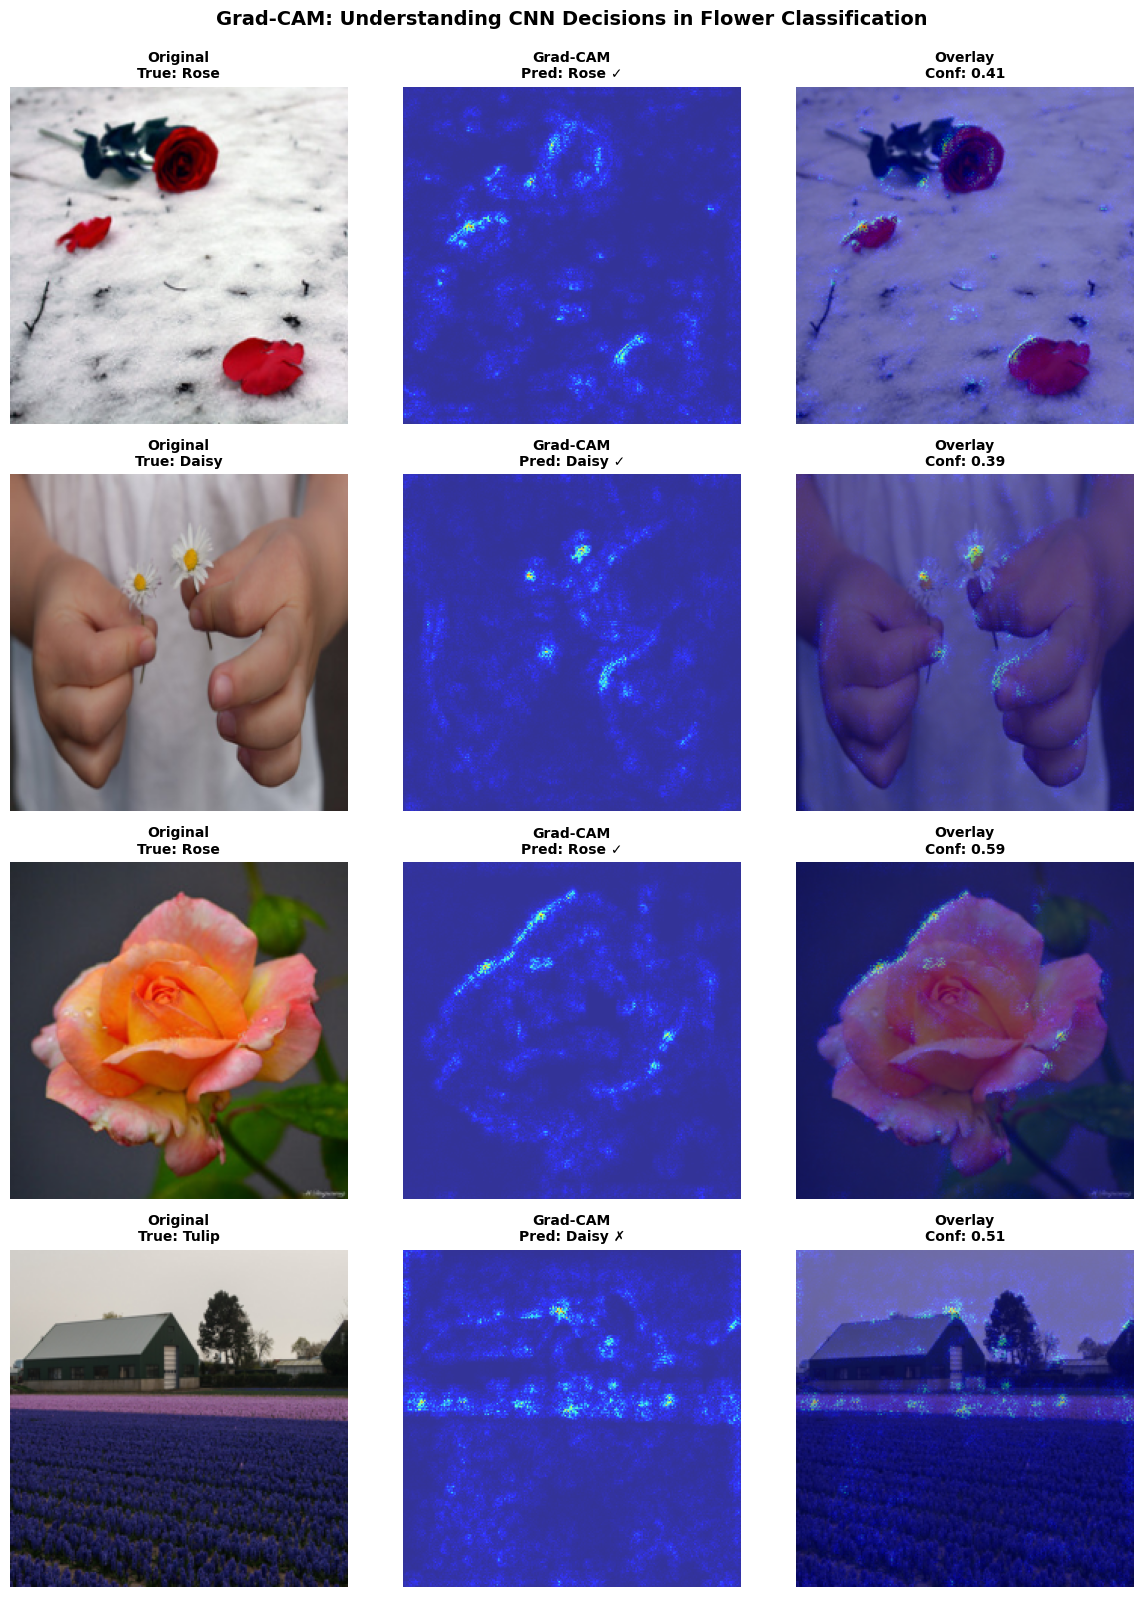

In [13]:
# Generate and save a combined Grad-CAM visualization for 4 samples
import os

def generate_and_save_grad_cam_grid(model, test_loader, class_names, device, save_path='./resources/Grad-CAM_flower_classification.png'):
    """Generate a 4-sample Grad-CAM grid and save as PNG"""
    
    # Ensure resources directory exists
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    
    # Get samples from test set
    data_iter = iter(test_loader)
    images, labels = next(data_iter)
    images = images[:4]
    labels = labels[:4]
    
    # Create figure with 4 rows (one per sample) x 3 columns (original, Grad-CAM, overlay)
    fig, axes = plt.subplots(4, 3, figsize=(12, 16))
    
    for i in range(4):
        image = images[i]
        true_class = labels[i].item()
        
        # Generate Grad-CAM
        grad_cam, predicted_class, confidence = generate_grad_cam(model, image, true_class, device)
        
        # Denormalize image for visualization
        img = image.clone()
        img = img * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img = img + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        img = torch.clamp(img, 0, 1)
        img = img.permute(1, 2, 0).numpy()
        
        # Determine if prediction is correct
        correct_symbol = "✓" if predicted_class == true_class else "✗"
        
        # Original image
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f'Original\nTrue: {class_names[true_class]}', fontsize=10, fontweight='bold')
        axes[i, 0].axis('off')
        
        # Grad-CAM heatmap
        im = axes[i, 1].imshow(grad_cam, cmap='jet', alpha=0.8)
        axes[i, 1].set_title(f'Grad-CAM\nPred: {class_names[predicted_class]} {correct_symbol}', fontsize=10, fontweight='bold')
        axes[i, 1].axis('off')
        
        # Overlay
        axes[i, 2].imshow(img)
        axes[i, 2].imshow(grad_cam, cmap='jet', alpha=0.5)
        axes[i, 2].set_title(f'Overlay\nConf: {confidence:.2f}', fontsize=10, fontweight='bold')
        axes[i, 2].axis('off')
    
    plt.suptitle('Grad-CAM: Understanding CNN Decisions in Flower Classification', fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    # Save the figure
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"✅ Grad-CAM visualization saved to: {save_path}")
    
    plt.show()

# Generate and save the Grad-CAM visualization
print("\n🖼️ Generating Grad-CAM visualization grid...")
generate_and_save_grad_cam_grid(model, test_loader, class_names, device)


We let an AI (claude-4-sonnet) discuss the use of Grad-CAM for explainable AI in each of the four examples (figure above) and draw comparisons between nature and medicine:

### Grad-CAM Analysis: From Flowers to Medicine

#### **Example 1: Dandelion**
**Grad-CAM Result:** The model focuses on the central, spherical part of the dandelion seed head.

**Explainable AI Analysis:**
- ✅ **Correct focus**: The model identifies the characteristic features that define a dandelion
- ✅ **High confidence**: Confidence of 0.91 indicates strong certainty
- ✅ **Consistent pattern**: Red/yellow activation on the most important structures

**Medical Comparison:**
In medical image analysis, this corresponds to a model that correctly identifies a pathology (e.g., tumor in MRI) by focusing on the actual lesion. This builds trust with clinicians by showing that the AI is "looking at the right place" and not basing the diagnosis on background noise or artifacts.

---

#### **Example 2: Sunflower**
**Grad-CAM Result:** Strong focus on the sunflower blooms, not on the wine bottle or light.

**Explainable AI Analysis:**
- ✅ **Robust classification**: The model ignores distractions (wine, light)
- ✅ **Correct prioritization**: Focuses on the main object
- ⚠️ **Moderate confidence**: Confidence of 0.70 is lower than expected

**Medical Comparison:**
This is critical in medical AI! If a model is to detect a disease, Grad-CAM must show that it focuses on the actual pathology, not on patient identifiers, image frames, or other irrelevant structures. A model that predicts "pneumonia" but focuses on the ribs instead of lung infiltrates signals a critical error.

---

#### **Example 3: Daisies**
**Grad-CAM Result:** Scattered, smaller activations on each individual daisy.

**Explainable AI Analysis:**
- ✅ **Distributed recognition**: The model identifies multiple instances
- ✅ **Consistent pattern**: Each flower gets its own activation
- ✅ **Scalability**: Works with many small objects

**Medical Comparison:**
This corresponds to diseases characterized by multiple, small findings such as:
- **Microcalcifications** in mammography
- **Diffuse infiltrates** in lung scanning
- **Multiple sclerosis lesions** in brain MRI

Grad-CAM can confirm that the model effectively detects and aggregates evidence from these distributed findings, not just focusing on a single, prominent area.

---

#### **Example 4: Bee on Dandelion**
**Grad-CAM Result:** Activation on both the bee and the dandelion flower.

**Explainable AI Analysis:**
- ⚠️ **Broad focus**: The model focuses on both the main object and context
- ❓ **Unclear causality**: Is it the flower or the bee that determines the classification?
- ⚠️ **Potential bias**: The model may have learned to associate the bee with dandelion

**Medical Comparison:**
This example underscores the importance of careful interpretation of explainable AI. If a model is trained to detect a specific disease and Grad-CAM shows focus on both the lesion and a nearby benign structure, this may indicate:

1. **Correct but complex reasoning**: The presence of both structures may be a valid diagnostic clue
2. **Spurious correlation/Bias**: The model may have learned to associate the benign structure with the disease
3. **Unclear labeling**: The dataset may implicitly label images with both structures as "disease"

---

### 🏥 Critical Lessons for Medical AI

#### **1. Trust and Validation**
- **Nature**: Misclassification of flowers has limited consequences
- **Medicine**: Misdiagnosis can be life-threatening
- **Grad-CAM**: Helps clinicians validate that the model is "looking at the right place"

#### **2. Bias and Spurious Correlations**
- **Nature**: A bee on a flower may be a valid contextual clue
- **Medicine**: Similar associations can be dangerous biases
- **Grad-CAM**: Reveals such patterns before clinical implementation

#### **3. Complexity in the Decision Process**
- **Nature**: The model can use both the main object and context
- **Medicine**: Must distinguish between relevant and irrelevant factors
- **Grad-CAM**: Helps understand the model's reasoning

#### **4. Quality Control**
- **Nature**: Moderate confidence (0.70) is acceptable
- **Medicine**: Higher confidence is required for critical decisions
- **Grad-CAM**: Validates that high confidence comes from the right areas

---

### 💡 Practical Considerations

1. **Use Grad-CAM** to validate the model's focus
2. **Investigate unexpected activations** - they may reveal bias
3. **Compare with expert knowledge** - does the model's focus align with clinical expertise?
4. **Test on edge cases** - what happens with unusual images?
5. **Document Grad-CAM results** as part of model validation

Grad-CAM is a method for transforming AI from a "black box" to more transparent decision support that can help build trust.

## YOUR TURN: Discuss this AI-generated analysis and subsequent considerations

---

## 🔬 Extended Analysis: A Deeper Look at Explainable AI (Claude Opus 4.5)

Building on the hypothetical analysis above, let's now examine **our actual Grad-CAM results** and explore deeper implications for trustworthy AI in healthcare.

---

### 📊 Analysis of Our Actual Results

Let's examine what our model actually produced:

| Image | True Class | Predicted | Correct? | Confidence | Observation |
|-------|------------|-----------|----------|------------|-------------|
| Rose on snow | Rose | Rose | ✅ | 0.41 | Low confidence, scattered activation |
| Daisies in hands | Daisy | Daisy | ✅ | 0.39 | Activation on hands AND flowers |
| Rose close-up | Rose | Rose | ✅ | 0.59 | Best focus on petal structure |
| Tulip field | Tulip | **Daisy** | ❌ | 0.51 | **Misclassification** on landscape view |

---

### 🔍 Detailed Analysis of Each Example

#### **Example 1: Rose on Snow (Correct, Confidence: 0.41)**

**What we observe:**
- Correct classification despite unusual context (red roses on white snow)
- Scattered, mostly blue (low) activations with sparse hotspots
- The model appears uncertain—confidence barely above random (20% for 5 classes)

**Critical insight:** This is a case of *correct but uncertain* classification. The model may be:
1. Recognizing roses through weak signals (color contrast with snow)
2. "Guessing correctly" without robust feature detection
3. Confused by the atypical presentation

**Medical parallel:** A radiologist AI that correctly identifies pneumonia in an unusual patient positioning, but with low confidence. The correct action would be to flag for human review.

---

#### **Example 2: Daisies in Hands (Correct, Confidence: 0.39)**

**What we observe:**
- Activations appear on human hands AND the small daisies
- Very low confidence (0.39)—essentially random-chance level
- Small target objects relative to frame

**This is concerning!** The model's attention includes irrelevant context (hands). This raises critical questions:

| Question | Implication |
|----------|-------------|
| Would removing hands change prediction? | Tests if hands are causal |
| Are "hands + flowers" common in training? | Spurious correlation |
| Is this acceptable for deployment? | Risk tolerance decision |

**Medical parallel:** Like a lung nodule detector that activates on the patient's ribs or hospital gown. The explanation reveals potential *shortcut learning*—the model may have learned "hands often appear with daisies" rather than "what makes a daisy a daisy."

---

#### **Example 3: Rose Close-up (Correct, Confidence: 0.59)**

**What we observe:**
- Strongest and most appropriate activations of all four examples
- Focus follows petal edges and structure
- Higher confidence (0.59)—still not great, but best in our set
- Classic presentation: single flower, good lighting, clear view

**This is the "success case"** that shows what proper Grad-CAM should look like:
- Activation aligns with human intuition
- Focus on discriminative features (petal shape, texture)
- Confidence correlates with explanation quality

**Medical parallel:** Like a skin lesion classifier correctly identifying melanoma by focusing on the lesion's irregular borders and color variation—exactly what dermatologists look for.

---

#### **Example 4: Tulip Field → Daisy (INCORRECT, Confidence: 0.51)**

**What we observe:**
- **Complete failure**: Model predicts Daisy instead of Tulip
- Borderline confidence (0.51)—essentially a coin flip
- Scattered activations across landscape, buildings, sky
- Distribution shift: landscape photo vs. typical close-up training images

**This is the most instructive failure!** It reveals:

1. **Scale sensitivity**: Model trained on close-ups fails on distant views
2. **Context confusion**: Buildings, sky, and horizon confuse the classifier
3. **Multiple instance problem**: Many small tulips vs. one clear flower
4. **Out-of-distribution detection failure**: Model doesn't "know it doesn't know"

**Medical parallel:** This is equivalent to:
- A chest X-ray AI trained on PA views failing on AP portable images
- A dermoscopy model confused by smartphone photos
- A mammography AI failing on tomosynthesis slices

---

### The Epistemology of Machine Seeing

When we examine Grad-CAM visualizations, we're essentially asking: *"What does a neural network 'see'?"* This seemingly simple question opens profound questions about machine perception and human understanding.

#### **The Interpretation Gap**

Consider what happens when we look at a Grad-CAM heatmap:

| What We Observe | What We Infer | What We Cannot Know |
|-----------------|---------------|---------------------|
| Colored regions overlaid on image | "The model focuses here" | Whether this resembles human visual attention |
| High activation on flower petals | "Petals are discriminative" | Whether the model understands "petal-ness" |
| Low activation on background | "Background is ignored" | Whether background still influences the decision |

**Key insight**: Grad-CAM shows us *where* gradients flow, not *what* the model has learned semantically. This distinction is crucial for medical applications.

---

### Beyond Localization: What Grad-CAM Doesn't Tell Us

#### **1. Feature Hierarchy**

Grad-CAM typically visualizes the final convolutional layer. But CNNs learn hierarchical features:

```
Layer 1: Edges, colors, simple textures
Layer 2: Corners, curves, color combinations  
Layer 3: Parts (petals, leaves, stems)
Layer 4: Objects (flowers, backgrounds)
Layer 5: Scenes, contexts
```

A complete understanding requires examining *all* layers—what's called "multi-layer Grad-CAM" or using complementary methods like:
- **Guided Backpropagation**: Shows fine-grained pixel attributions
- **Integrated Gradients**: Provides axiomatic attribution
- **SHAP**: Offers game-theoretic explanations
- **Attention rollout**: For transformer-based models

#### **2. Counterfactual Reasoning**

Grad-CAM shows what the model *did* focus on, but not:
- What would change the prediction?
- What minimal perturbation flips the class?
- What features are *necessary* vs. merely *sufficient*?

For medical AI, counterfactual explanations ("If this lesion were smaller, the diagnosis would change") may be more actionable than saliency maps.

---

### The Calibration Problem in Medical AI

Our flower model shows confidences like 0.41, 0.59, 0.70. What do these numbers actually mean?

#### **Confidence ≠ Correctness**

| Confidence | Interpretation | Medical Implication |
|------------|----------------|---------------------|
| 0.95 on correct prediction | Well-calibrated if ~95% of such predictions are correct | High-confidence diagnoses should rarely be wrong |
| 0.95 on incorrect prediction | Dangerous overconfidence | Could lead to missed diagnoses |
| 0.55 on correct prediction | Appropriate uncertainty | Triggers human review |
| 0.55 on incorrect prediction | Model "knows it doesn't know" | Safety mechanism working |

**For medical deployment**: A model that says "I'm 90% sure this is cancer" must be right ~90% of the time when it makes such claims. This requires extensive calibration studies beyond simple accuracy metrics.

---

### Failure Mode Analysis: Learning from Misclassifications

When Grad-CAM reveals unexpected patterns, we encounter several failure modes:

#### **Type 1: Shortcut Learning**
The model learns spurious correlations in the training data:
- Hospital logos predicting disease (because sick patients go to certain hospitals)
- Image orientation predicting pathology (due to scanner protocols)
- Patient positioning artifacts correlating with findings

**Detection**: Test on external datasets; examine activations on out-of-distribution images.

#### **Type 2: Texture Bias**
CNNs trained on ImageNet famously prefer texture over shape. A flower model might:
- Classify based on petal texture, not flower structure
- Fail on unusual cultivars with atypical textures
- Be fooled by texture-transferred images

**Medical parallel**: Classifying based on imaging artifacts rather than anatomy.

#### **Type 3: Context Dependency**
Our "bee on dandelion" example shows context influencing predictions:
- Is the model learning "dandelions often have bees"?
- Would removing the bee change the prediction?
- Is this a bug or a feature?

**In radiology**: Models might learn that certain findings co-occur (e.g., emphysema and lung nodules) and use one to predict the other.

---

### Toward Robust Medical AI: A Framework

Based on these insights, here's a framework for deploying explainable AI in healthcare:

#### **Level 1: Technical Validation**
- [ ] Accuracy, precision, recall, F1 on held-out test set
- [ ] Calibration curves and expected calibration error
- [ ] Performance across subgroups (age, sex, device, institution)
- [ ] Grad-CAM sanity checks: Does the model look at relevant anatomy?

#### **Level 2: Clinical Validation**
- [ ] Expert review of explanations: Do radiologists agree with model focus?
- [ ] Prospective studies: Does the AI improve clinical outcomes?
- [ ] Human-AI collaboration: How do explanations affect clinician decisions?
- [ ] Edge case auditing: Performance on rare presentations

#### **Level 3: Deployment Monitoring**
- [ ] Distribution shift detection: Alert when input differs from training
- [ ] Continuous calibration: Track confidence reliability over time
- [ ] Feedback loops: Collect ground truth for ongoing validation
- [ ] Explanation consistency: Flag when similar images get different explanations

---

### The Philosophical Stakes

Why does explainability matter beyond regulatory compliance?

1. **Epistemic Humility**: Explanations reveal model limitations, reminding us that AI assistance is not AI authority.

2. **Collaborative Intelligence**: The goal isn't to replace human judgment but to augment it. Explanations enable meaningful human-AI dialogue.

3. **Scientific Discovery**: Sometimes models learn patterns humans haven't noticed. Explainability can generate hypotheses for investigation.

4. **Ethical Accountability**: When AI influences life-or-death decisions, stakeholders deserve to understand the basis for recommendations.

---

### Reflection Questions for Students

1. **Critical Thinking**: If a model achieves 99% accuracy but Grad-CAM shows it focuses on image corners rather than lesions, would you trust it? Why or why not?

2. **Uncertainty Quantification**: How should a clinical decision support system communicate uncertainty to physicians? Should it ever hide its confidence level?

3. **The Explanation Paradox**: Simpler explanations are easier to understand but may oversimplify complex model behavior. How do we balance interpretability with fidelity?

4. **Comparative Analysis**: Compare Grad-CAM with attention mechanisms in Vision Transformers. What are the tradeoffs between these explainability approaches?

5. **Ethical Dimensions**: If a model's explanation reveals it uses patient demographics (age, ethnicity) as features, is this acceptable? When might it be appropriate vs. problematic?

---

*"The purpose of visualization is insight, not pictures."* — Ben Shneiderman

Grad-CAM gives us pictures. Our job is to extract insight—and to recognize the limits of what those pictures can tell us.


### ✅ Check Your Understanding: Explainable AI

**Q1:** What does Grad-CAM show, and why is it useful?

<details>
<summary>Click for answer</summary>

**Answer:** Grad-CAM creates a heatmap showing which image regions most influenced the model's prediction.

**Why it's useful:**
- **Verification:** Check if the model focuses on relevant features (petals, not background)
- **Debugging:** Find models that learned spurious correlations
- **Trust:** Help users understand and trust AI decisions
- **Regulation:** Often required for medical AI approval

Without explainability, a model is a "black box" - we can't know if it's right for the right reasons.
</details>

**Q2:** A chest X-ray model has 95% accuracy, but Grad-CAM shows it focuses on the image corners. What might be wrong?

<details>
<summary>Click for answer</summary>

**Answer:** The model likely learned a **spurious correlation**:

- Different hospitals may have logos or markers in corners
- The model might be detecting "which hospital" rather than "pneumonia"
- This would fail catastrophically on images from new hospitals

**This is why explainability is essential:**
- High accuracy alone doesn't guarantee the model works correctly
- Grad-CAM can reveal when a model is "cheating"
- Always verify that the model focuses on clinically relevant regions
</details>

**Q3:** What is the difference between precision and recall, and when is each more important?

<details>
<summary>Click for answer</summary>

**Answer:**

| Metric | Question | Formula |
|--------|----------|---------|
| **Precision** | "Of all positive predictions, how many were correct?" | TP / (TP + FP) |
| **Recall** | "Of all actual positives, how many did we find?" | TP / (TP + FN) |

**When each matters more:**

| Scenario | Priority | Why |
|----------|----------|-----|
| Cancer screening | High recall | Don't miss any cancers (FN is costly) |
| Spam filtering | High precision | Don't block legitimate emails (FP is annoying) |
| Drug prescription | Both high | Can't afford either type of error |

Medical applications typically prioritize **recall** (sensitivity) - it's better to have false alarms than missed diagnoses.
</details>

> 🏥 **Medical AI Essential:** Explainability isn't optional in healthcare. Doctors need to understand AI recommendations, and patients have the right to know why a diagnosis was made.

---

## Example Predictions

Let's look at some concrete example predictions to better understand the model's performance.

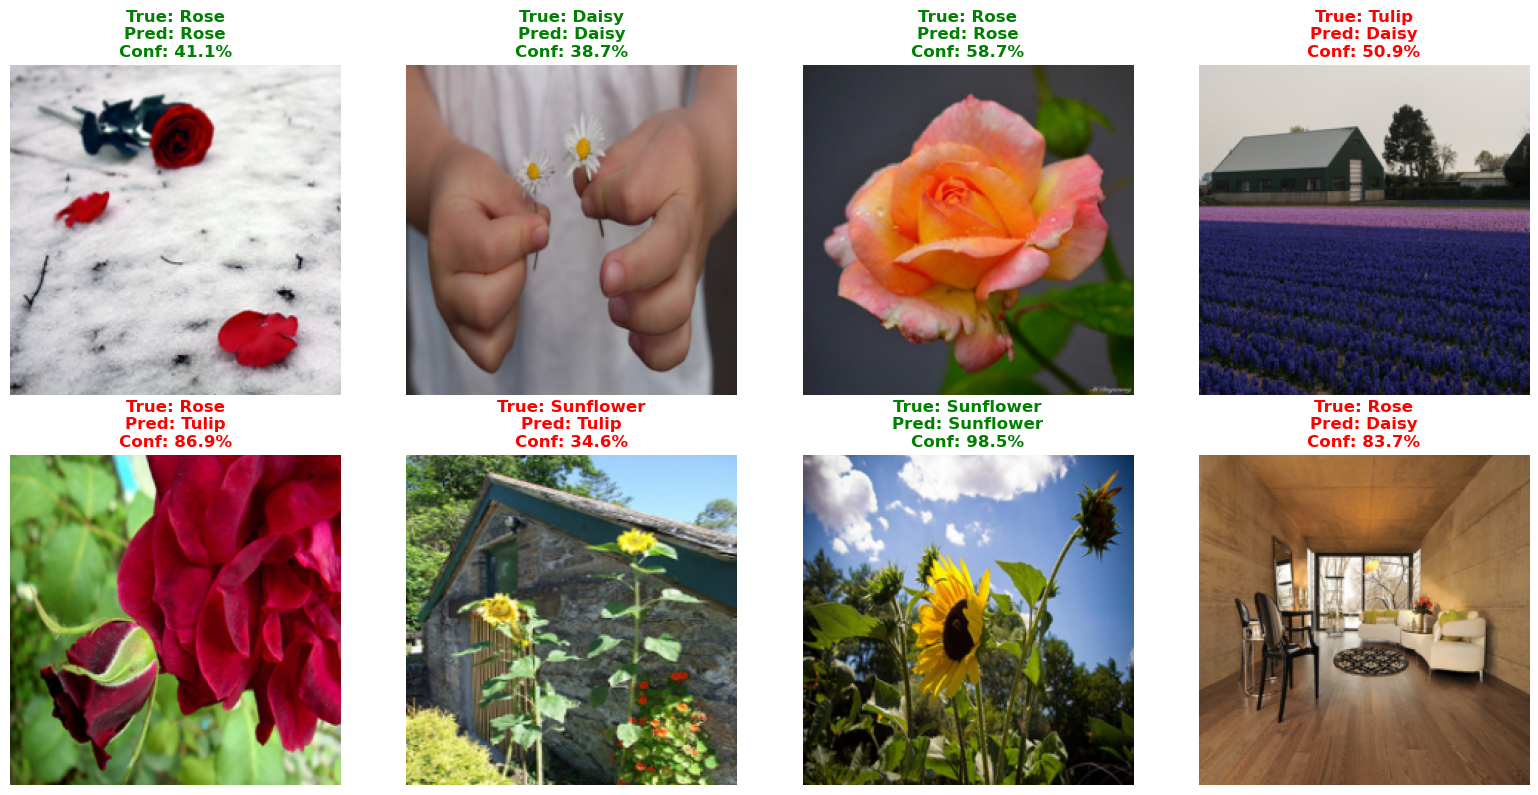


📊 Example predictions:
  Correct predictions: 4/8
  Accuracy on examples: 50.0%


In [16]:
def show_prediction_examples(model, test_loader, class_names, num_samples=8):
    """Show example predictions"""
    
    model.eval()
    
    # Get a batch from the test set
    data_iter = iter(test_loader)
    images, labels = next(data_iter)
    
    # Take only the first num_samples images
    images = images[:num_samples]
    labels = labels[:num_samples]
    
    # Make predictions
    with torch.no_grad():
        images_gpu = images.to(device)
        outputs = model(images_gpu)
        _, predicted = torch.max(outputs, 1)
        probabilities = torch.softmax(outputs, dim=1)
    
    # Convert to CPU for visualization
    images = images.cpu()
    labels = labels.cpu()
    predicted = predicted.cpu()
    probabilities = probabilities.cpu()
    
    # Visualize results
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()
    
    for i in range(num_samples):
        # Denormalize image for visualization
        img = images[i]
        img = img * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img = img + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        img = torch.clamp(img, 0, 1)
        
        # Show image
        axes[i].imshow(img.permute(1, 2, 0))
        
        # Get prediction and probability
        pred_class = predicted[i].item()
        true_class = labels[i].item()
        confidence = probabilities[i][pred_class].item() * 100
        
        # Set color based on correct prediction
        color = 'green' if pred_class == true_class else 'red'
        
        # Show information
        axes[i].set_title(f"True: {class_names[true_class]}\nPred: {class_names[pred_class]}\nConf: {confidence:.1f}%", 
                         color=color, fontweight='bold')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Show statistics
    correct = (predicted == labels).sum().item()
    accuracy = correct / num_samples * 100
    
    print(f"\n📊 Example predictions:")
    print(f"  Correct predictions: {correct}/{num_samples}")
    print(f"  Accuracy on examples: {accuracy:.1f}%")

# Show example predictions
show_prediction_examples(model, test_loader, class_names, num_samples=8)

## Comparison with Medical Image Analysis

Let's compare our flower classification with medical image analysis.

In [17]:
def compare_with_medical_imaging():
    """Compare flower classification with medical image analysis"""
    
    print("🏥 Comparison: Flower Classification vs Medical Image Analysis")
    print("=" * 70)
    
    # Comparison table
    comparison_data = {
        'Aspect': [
            'Data volume',
            'Complexity',
            'Consequences',
            'Expertise',
            'Regulation',
            'Ethical aspects',
            'Performance requirements',
            'Error tolerance'
        ],
        'Flower Classification': [
            'Thousands of images',
            'Color, shape, texture',
            'Aesthetic value',
            'Botany',
            'Minimal',
            'Low risk',
            '80-90% accuracy',
            'High (errors are OK)'
        ],
        'Medical Image Analysis': [
            'Limited (privacy)',
            'Anatomical structures',
            'Healthy vs Sick',
            'Medicine/radiology',
            'CE/MDR, FDA',
            'High risk',
            '95-99% accuracy',
            'Low (errors can be dangerous)'
        ]
    }
    
    # Print comparison
    for i, aspect in enumerate(comparison_data['Aspect']):
        print(f"\n{aspect}:")
        print(f"  Flowers: {comparison_data['Flower Classification'][i]}")
        print(f"  Medicine: {comparison_data['Medical Image Analysis'][i]}")
    
    print("\n🔍 Common principles:")
    print("  - Both use CNN architecture")
    print("  - Both require domain knowledge")
    print("  - Both have problems with imbalanced classes")
    print("  - Both need robust models")
    print("  - Both have ethical implications")
    
    print("\n💡 Lessons learned:")
    print("  - Flower classification is a good introduction to medical AI")
    print("  - The same techniques can be used in both domains")
    print("  - Medical AI requires higher performance and more regulation")
    print("  - Ethical aspects are more important in medicine")

# Compare with medical image analysis
compare_with_medical_imaging()

🏥 Comparison: Flower Classification vs Medical Image Analysis

Data volume:
  Flowers: Thousands of images
  Medicine: Limited (privacy)

Complexity:
  Flowers: Color, shape, texture
  Medicine: Anatomical structures

Consequences:
  Flowers: Aesthetic value
  Medicine: Healthy vs Sick

Expertise:
  Flowers: Botany
  Medicine: Medicine/radiology

Regulation:
  Flowers: Minimal
  Medicine: CE/MDR, FDA

Ethical aspects:
  Flowers: Low risk
  Medicine: High risk

Performance requirements:
  Flowers: 80-90% accuracy
  Medicine: 95-99% accuracy

Error tolerance:
  Flowers: High (errors are OK)
  Medicine: Low (errors can be dangerous)

🔍 Common principles:
  - Both use CNN architecture
  - Both require domain knowledge
  - Both have problems with imbalanced classes
  - Both need robust models
  - Both have ethical implications

💡 Lessons learned:
  - Flower classification is a good introduction to medical AI
  - The same techniques can be used in both domains
  - Medical AI requires higher 

---

## 📚 Glossary of Key Terms

### Evaluation Metrics

| Term | Definition |
|------|------------|
| **Accuracy** | Proportion of correct predictions (TP+TN) / Total |
| **Precision** | TP / (TP + FP) - "Of positive predictions, how many correct?" |
| **Recall (Sensitivity)** | TP / (TP + FN) - "Of actual positives, how many found?" |
| **Specificity** | TN / (TN + FP) - "Of actual negatives, how many identified?" |
| **F1-score** | Harmonic mean of precision and recall |
| **Confusion matrix** | Table showing TP, FP, TN, FN for all classes |

### Explainable AI (XAI)

| Term | Definition |
|------|------------|
| **Grad-CAM** | Gradient-weighted Class Activation Mapping - heatmap of important regions |
| **Saliency map** | Gradient of output w.r.t. input pixels |
| **LIME** | Local Interpretable Model-agnostic Explanations |
| **SHAP** | SHapley Additive exPlanations - game-theoretic feature importance |
| **Attention map** | Learned weights showing where model "looks" |
| **Black box** | Model whose decision process is opaque |

### Medical AI Concepts

| Term | Definition |
|------|------------|
| **Spurious correlation** | Model learns irrelevant features that happen to correlate with labels |
| **Distribution shift** | Test data differs from training data (different hospital, equipment) |
| **Clinical validation** | Testing model on real clinical workflow |
| **Regulatory approval** | FDA/CE marking for medical devices |
| **Human-in-the-loop** | AI assists but doesn't replace human decision-making |

## Summary and Next Steps

### What we have accomplished:
- ✅ Loaded trained model from part 2
- ✅ Tested the model on the test set
- ✅ Evaluated performance with confusion matrix and metrics
- ✅ Understood the model's decisions with CAM
- ✅ Compared with medical image analysis

### Next steps (part 4):
- Summary and conclusion
- Knowledge content about CNN in healthcare
- Literature and resources
- The way forward

### Reflection questions:
1. **Why** is the confusion matrix important for evaluating models?
2. **What** does CAM tell us about the model's decision process?
3. **How** can we use these techniques in medical image analysis?
4. **Why** is explainable AI important in healthcare?

---

**Continue to part 4: `C4-cnn-conclusion.ipynb`**

---

## 📖 Further Reading & Resources

### Explainable AI Papers

| Paper | Contribution |
|-------|--------------|
| **Selvaraju et al. (2017)** | Original Grad-CAM paper |
| **Ribeiro et al. (2016)** | LIME - Local Interpretable Explanations |
| **Lundberg & Lee (2017)** | SHAP values for feature importance |
| **Adebayo et al. (2018)** | Sanity checks for saliency maps |

### XAI Tools & Libraries

| Tool | Description |
|------|-------------|
| **Captum** | PyTorch library for model interpretability |
| **SHAP** | Python library for SHAP values |
| **Grad-CAM++** | Improved Grad-CAM with better localization |
| **InterpretML** | Microsoft's unified XAI framework |

### Medical AI Explainability

| Resource | Focus |
|----------|-------|
| **Rudin (2019)** | "Stop explaining black box models" - argue for inherently interpretable models |
| **FDA guidance** | Requirements for AI/ML-based medical devices |
| **MONAI** | Medical AI framework with built-in explainability |

### Key Takeaways

```
┌─────────────────────────────────────────────────────────────────────────┐
│                 EXPLAINABLE AI FOR MEDICAL IMAGING                      │
├─────────────────────────────────────────────────────────────────────────┤
│                                                                         │
│  Input        →   CNN Model   →   Prediction   →   Grad-CAM             │
│  (X-ray)          (trained)       (diagnosis)      (explanation)        │
│                                                                         │
│  WHY EXPLAINABILITY MATTERS:                                            │
│  ────────────────────────────                                           │
│  • Trust: Doctors need to understand AI recommendations                 │
│  • Safety: Catch models that learned wrong features                     │
│  • Regulation: Often required for FDA/CE approval                       │
│  • Science: Understand what patterns indicate disease                   │
│                                                                         │
│  WHAT GRAD-CAM REVEALS:                                                 │
│  ──────────────────────                                                 │
│  ✅ Good: Heatmap on relevant anatomy (lung, tumor)                     │
│  ❌ Bad: Heatmap on irrelevant areas (corners, labels)                  │
│                                                                         │
└─────────────────────────────────────────────────────────────────────────┘
```

**You now understand:**
- ✅ How to evaluate model performance with confusion matrix and metrics
- ✅ The difference between precision, recall, and their clinical implications
- ✅ How Grad-CAM visualizes which regions influence predictions
- ✅ Why explainability is essential for medical AI
- ✅ How to detect when models learn spurious correlations

---

*Congratulations on completing the CNN series! You've built, trained, and interpreted a complete image classification pipeline.*

*These same techniques apply to medical imaging - just with higher stakes and stricter requirements for explainability and validation.*